# PEGI Classification — Hybrid Unsupervised + Supervised Pipeline

**Obiettivo:** Prevedere la classe PEGI di un videogioco (3, 7, 12, 16, 18) a partire dai soli **tag di contenuto** Steam.

**Strategia ibrida:**
1. **KMeans** sui tag binari → distanze geometriche dai centroidi (feature di contesto non supervisionate)
2. **Combinazione** tag originali + distanze KMeans
3. **Random Forest** con `class_weight='balanced'` sul dataset arricchito
4. **Evaluation** con classification report + Feature Importance

---

## 0. Setup & Imports

In [18]:
import warnings
warnings.filterwarnings('ignore')

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerie caricate correttamente')

Librerie caricate correttamente


---
## 1. Caricamento e Pre-processing del Dataset

In [19]:
# ── Carica il dataset ────────────────────────────────────────────────────────
df_raw = pd.read_csv('for_EDA.csv')
print(f'Dataset grezzo: {df_raw.shape[0]:,} righe × {df_raw.shape[1]} colonne')

# ── Filtra solo i giochi con rating PEGI ufficiale ───────────────────────────
PEGI_CLASSES = [3.0, 7.0, 12.0, 16.0, 18.0]
df = df_raw[df_raw['age_rating'].isin(PEGI_CLASSES)].copy()
df['pegi'] = df['age_rating'].astype(int)        # label intera: 3, 7, 12, 16, 18
df = df.reset_index(drop=True)
print(f'Dataset filtrato PEGI: {len(df):,} giochi\n')

# ── Distribuzione classi ─────────────────────────────────────────────────────
dist = df['pegi'].value_counts().sort_index()
print('Distribuzione classi PEGI:')
for cls, cnt in dist.items():
    bar = '█' * (cnt // 100)
    print(f'  PEGI {cls:>2}: {cnt:>5} giochi  {bar}')

Dataset grezzo: 103,976 righe × 21 colonne
Dataset filtrato PEGI: 16,524 giochi

Distribuzione classi PEGI:
  PEGI  3:  3954 giochi  ███████████████████████████████████████
  PEGI  7:  1923 giochi  ███████████████████
  PEGI 12:  5191 giochi  ███████████████████████████████████████████████████
  PEGI 16:  3164 giochi  ███████████████████████████████
  PEGI 18:  2292 giochi  ██████████████████████


In [20]:
# ── Parsing dei tag da stringa Python-like a lista ───────────────────────────
def parse_tags(raw: str) -> list:
    """Converte la stringa '["tag1", "tag2", ...]' in una lista Python."""
    try:
        return ast.literal_eval(raw)
    except Exception:
        return []

df['tags_parsed'] = df['tags'].apply(parse_tags)

# Verifica
print('Esempio tag parsed:', df['tags_parsed'].iloc[1])

Esempio tag parsed: ['Action', 'Adventure', 'Singleplayer', 'Story Rich', 'Mythology', 'Third Person', 'Combat', 'RPG', 'Violent', 'Fantasy', 'Exploration', 'Hack and Slash', 'Atmospheric', 'Gore', 'Emotional', 'Action RPG', '3D', 'Souls-like', 'PvE', 'Crafting']


In [21]:
# ── Selezione del vocabolario di tag (freq ≥ 50) ────────────────────────────
all_tags_flat = [tag for tags in df['tags_parsed'] for tag in tags]
tag_counts    = Counter(all_tags_flat)

MIN_FREQ      = 50
VOCAB         = sorted([tag for tag, cnt in tag_counts.items() if cnt >= MIN_FREQ])
print(f'Vocabolario selezionato (freq ≥ {MIN_FREQ}): {len(VOCAB)} tag unici')

# Tag PEGI-rilevanti presenti nel vocabolario
pegi_relevant = ['Violent', 'Gore', 'Nudity', 'Sexual Content', 'Mature',
                 'Horror', 'Blood', 'Family Friendly', 'Adult Only 18+']
print('\nTag PEGI-rilevanti inclusi nel vocabolario:')
for t in pegi_relevant:
    status = 'Incluso' if t in VOCAB else 'Escluso'
    print(f'  {status}  {t} ({tag_counts.get(t, 0)} occorrenze)')

Vocabolario selezionato (freq ≥ 50): 245 tag unici

Tag PEGI-rilevanti inclusi nel vocabolario:
  Incluso  Violent (1660 occorrenze)
  Incluso  Gore (1414 occorrenze)
  Incluso  Nudity (828 occorrenze)
  Incluso  Sexual Content (783 occorrenze)
  Incluso  Mature (103 occorrenze)
  Incluso  Horror (705 occorrenze)
  Incluso  Blood (79 occorrenze)
  Incluso  Family Friendly (824 occorrenze)
  Escluso  Adult Only 18+ (0 occorrenze)


In [22]:
# ── Costruzione matrice binaria tag (One-Hot encoding manuale) ───────────────
vocab_index = {tag: i for i, tag in enumerate(VOCAB)}
n_samples   = len(df)
n_features  = len(VOCAB)

X_tags = np.zeros((n_samples, n_features), dtype=np.float32)

for i, tags in enumerate(df['tags_parsed']):
    for tag in tags:
        if tag in vocab_index:
            X_tags[i, vocab_index[tag]] = 1.0

tag_col_names = [f'tag_{t}' for t in VOCAB]

print(f'Matrice tag binaria: {X_tags.shape}  (campioni × tag)')
print(f'Densità media: {X_tags.mean():.3f} ({X_tags.mean()*100:.1f}% delle celle = 1)')

# Target
y = df['pegi'].values
print(f'\nTarget y: {y.shape}, classi: {np.unique(y)}')

Matrice tag binaria: (16524, 245)  (campioni × tag)
Densità media: 0.025 (2.5% delle celle = 1)

Target y: (16524,), classi: [ 3  7 12 16 18]


---
## 2. STEP UNSUPERVISED — KMeans Clustering & Feature Engineering

> **Idea chiave:** invece di usare il solo ID del cluster (1 feature discreta),
> usiamo `.transform()` per ottenere la **distanza euclidea di ogni gioco
> da tutti i centroidi**. Ogni distanza diventa una feature continua che
> cattura la posizione geometrica del gioco nello spazio dei tag.

In [23]:
# ── Scelta del numero ottimale di cluster: Inertia Elbow Curve ──────────────
K_RANGE  = range(3, 21)
inertias = []

print('Calcolo inertia per k =', list(K_RANGE), '...')
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    km.fit(X_tags)
    inertias.append(km.inertia_)
    print(f'  k={k:>2}  inertia={km.inertia_:,.1f}')

print('\n✅ Done')

Calcolo inertia per k = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] ...
  k= 3  inertia=77,748.1
  k= 4  inertia=75,319.6
  k= 5  inertia=73,265.1
  k= 6  inertia=71,710.7
  k= 7  inertia=70,223.6
  k= 8  inertia=68,747.1
  k= 9  inertia=67,369.6
  k=10  inertia=66,710.1
  k=11  inertia=65,386.5
  k=12  inertia=64,679.9
  k=13  inertia=63,932.0
  k=14  inertia=63,633.9
  k=15  inertia=62,799.7
  k=16  inertia=61,833.0
  k=17  inertia=61,334.1
  k=18  inertia=60,757.4
  k=19  inertia=60,229.2
  k=20  inertia=59,982.0

✅ Done


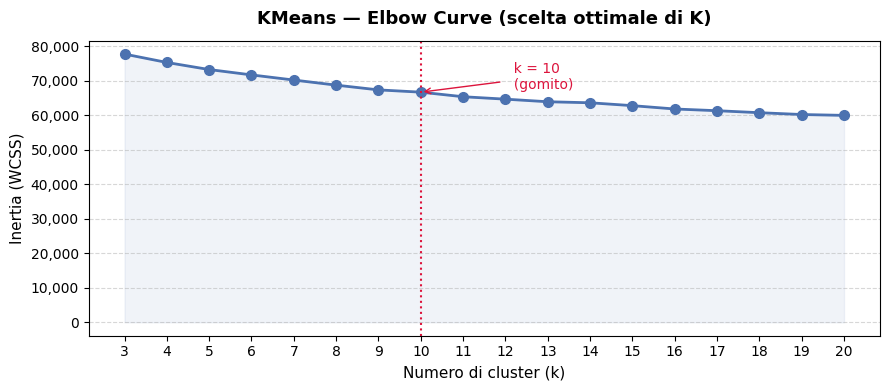


→ K ottimale scelto: 10


In [24]:
# ── Elbow Plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(list(K_RANGE), inertias, 'o-', color='#4C72B0', linewidth=2, markersize=7)
ax.fill_between(list(K_RANGE), inertias, alpha=0.08, color='#4C72B0')

ax.set_title('KMeans — Elbow Curve (scelta ottimale di K)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Numero di cluster (k)', fontsize=11)
ax.set_ylabel('Inertia (WCSS)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xticks(list(K_RANGE))

# Annota manualmente il gomito visibile
K_OPTIMAL = 10
idx_opt   = list(K_RANGE).index(K_OPTIMAL)
ax.annotate(f'  k = {K_OPTIMAL}\n  (gomito)', xy=(K_OPTIMAL, inertias[idx_opt]),
            fontsize=10, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson'),
            xytext=(K_OPTIMAL + 2, inertias[idx_opt] + (max(inertias)-min(inertias))*0.05))
ax.axvline(K_OPTIMAL, color='crimson', linestyle=':', linewidth=1.5)

plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n→ K ottimale scelto: {K_OPTIMAL}')

In [25]:
# ── Fit KMeans finale con K ottimale ────────────────────────────────────────
K_OPTIMAL = 10   # ← modifica se l'elbow suggerisce un valore diverso

kmeans = KMeans(
    n_clusters   = K_OPTIMAL,
    random_state = RANDOM_STATE,
    n_init       = 20,          # più restarts = centroidi più stabili
    max_iter     = 500
)
kmeans.fit(X_tags)

print(f'KMeans addestrato: {K_OPTIMAL} cluster')
print(f'Inertia finale: {kmeans.inertia_:,.1f}')
print(f'\nDistribuzione campioni per cluster:')
cluster_labels = kmeans.labels_
for c, cnt in sorted(Counter(cluster_labels).items()):
    bar = '█' * (cnt // 50)
    print(f'  Cluster {c:>2}: {cnt:>5} giochi  {bar}')

KMeans addestrato: 10 cluster
Inertia finale: 66,268.3

Distribuzione campioni per cluster:
  Cluster  0:   945 giochi  ██████████████████
  Cluster  1:  2095 giochi  █████████████████████████████████████████
  Cluster  2:  4049 giochi  ████████████████████████████████████████████████████████████████████████████████
  Cluster  3:   851 giochi  █████████████████
  Cluster  4:   699 giochi  █████████████
  Cluster  5:  2112 giochi  ██████████████████████████████████████████
  Cluster  6:  3190 giochi  ███████████████████████████████████████████████████████████████
  Cluster  7:   825 giochi  ████████████████
  Cluster  8:   981 giochi  ███████████████████
  Cluster  9:   777 giochi  ███████████████


In [26]:
# ── Generazione feature di distanza con .transform() ────────────────────────
#
# .transform() restituisce shape (n_samples, K_OPTIMAL):
# ogni colonna è la distanza euclidea dal centroide del cluster k.
#
X_distances = kmeans.transform(X_tags)           # shape: (16524, 10)
dist_col_names = [f'dist_cluster_{k}' for k in range(K_OPTIMAL)]

print(f'Matrice distanze KMeans: {X_distances.shape}')
print(f'Range valori: [{X_distances.min():.4f}, {X_distances.max():.4f}]')
print(f'Media per cluster:\n', np.round(X_distances.mean(axis=0), 4))

Matrice distanze KMeans: (16524, 10)
Range valori: [0.3405, 4.9115]
Media per cluster:
 [2.7219 2.1726 2.1961 2.6417 2.8543 2.2594 2.155  2.8342 2.6769 2.8989]


---
## 3. COMBINAZIONE FEATURE

Concateniamo orizzontalmente:
- **245 tag binari** (prospettiva supervisionata classica)
- **10 distanze KMeans** (prospettiva non supervisionata)

→ Dataset finale arricchito: **255 feature**

In [27]:
# ── Concatenazione tag binari + distanze KMeans ──────────────────────────────
X_hybrid   = np.hstack([X_tags, X_distances])                       # (16524, 255)
all_col_names = tag_col_names + dist_col_names

print('=' * 50)
print(f'  Tag binari originali :  {X_tags.shape[1]:>5} feature')
print(f'  Distanze KMeans      :  {X_distances.shape[1]:>5} feature')
print(f'  ─────────────────────────────────')
print(f'  Dataset IBRIDO finale:  {X_hybrid.shape[1]:>5} feature  ×  {X_hybrid.shape[0]:,} campioni')
print('=' * 50)

  Tag binari originali :    245 feature
  Distanze KMeans      :     10 feature
  ─────────────────────────────────
  Dataset IBRIDO finale:    255 feature  ×  16,524 campioni


---
## 4. STEP SUPERVISED — Random Forest Classifier

> **`class_weight='balanced'`** penalizza automaticamente gli errori sulle
> classi rare (PEGI 7 e 18) in proporzione inversa alla loro frequenza.
> Questo risolve il principale problema dei risultati mediocri precedenti.

In [28]:
# ── Train / Test Split stratificato ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y          # mantiene le proporzioni PEGI nel split
)

print(f'Train: {X_train.shape[0]:,} campioni  |  Test: {X_test.shape[0]:,} campioni')
print('\nDistribuzione PEGI nel training set:')
for cls, cnt in sorted(Counter(y_train).items()):
    pct = cnt / len(y_train) * 100
    print(f'  PEGI {cls:>2}: {cnt:>5} ({pct:.1f}%)')

Train: 13,219 campioni  |  Test: 3,305 campioni

Distribuzione PEGI nel training set:
  PEGI  3:  3163 (23.9%)
  PEGI  7:  1538 (11.6%)
  PEGI 12:  4153 (31.4%)
  PEGI 16:  2531 (19.1%)
  PEGI 18:  1834 (13.9%)


In [29]:
import pandas as pd
import numpy as np
import ast
from collections import Counter
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42 # Defined here for robustness

# --- Riproposizione di tutti i passaggi necessari per definire X_hybrid e y ---
# Questi passaggi sono stati spostati qui per rendere la cella autonoma
# e risolvere i problemi di 'NameError' dovuti allo stato del kernel.

# ── Carica il dataset e filtra PEGI (da ziYD45H0rST0) ────────────────────────
df_raw = pd.read_csv('for_EDA.csv')
PEGI_CLASSES = [3.0, 7.0, 12.0, 16.0, 18.0]
df = df_raw[df_raw['age_rating'].isin(PEGI_CLASSES)].copy()
df['pegi'] = df['age_rating'].astype(int)
df = df.reset_index(drop=True)

# ── Parsing dei tag (da U2lvXA7TrST0) ───────────────────────────────────────
def parse_tags(raw: str) -> list:
    try:
        return ast.literal_eval(raw)
    except Exception:
        return []
df['tags_parsed'] = df['tags'].apply(parse_tags)

# ── Selezione del vocabolario di tag (da rKHzFijwrST0) ──────────────────────
all_tags_flat = [tag for tags in df['tags_parsed'] for tag in tags]
tag_counts    = Counter(all_tags_flat)
MIN_FREQ      = 50 # Assunto dal notebook
VOCAB         = sorted([tag for tag, cnt in tag_counts.items() if cnt >= MIN_FREQ])

# ── Costruzione matrice binaria tag e target y (da XYfWId-XrST1) ────────────
vocab_index = {tag: i for i, tag in enumerate(VOCAB)}
n_samples   = len(df)
n_features  = len(VOCAB)
X_tags = np.zeros((n_samples, n_features), dtype=np.float32)
for i, tags in enumerate(df['tags_parsed']):
    for tag in tags:
        if tag in vocab_index:
            X_tags[i, vocab_index[tag]] = 1.0
tag_col_names = [f'tag_{t}' for t in VOCAB]
y = df['pegi'].values

# ── Fit KMeans con K ottimale (da rLx2nUeTrST2) ─────────────────────────────
K_OPTIMAL = 10 # Assunto dal notebook
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=20, max_iter=500)
kmeans.fit(X_tags)

# ── Generazione feature di distanza (da C-87H5URrST2) ───────────────────────
X_distances = kmeans.transform(X_tags)
dist_col_names = [f'dist_cluster_{k}' for k in range(K_OPTIMAL)]

# ── Concatenazione feature ibride (da FdhgkrcDrST2) ─────────────────────────
X_hybrid   = np.hstack([X_tags, X_distances])
all_col_names = tag_col_names + dist_col_names

# --- Fine riproposizione dei passaggi ---

# ── Train / Test Split stratificato (Spostato da cella precedente S5eMWtHVrST3) ──────────
X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y          # mantiene le proporzioni PEGI nel split
)

print(f'Train: {X_train.shape[0]:,} campioni  |  Test: {X_test.shape[0]:,} campioni')
print('\nDistribuzione PEGI nel training set:')
for cls, cnt in sorted(Counter(y_train).items()):
    pct = cnt / len(y_train) * 100
    print(f'  PEGI {cls:>2}: {cnt:>5} ({pct:.1f}%)')

rf_model = RandomForestClassifier(
    n_estimators  = 400,              # Aumentato il numero di alberi per maggiore robustezza
    max_depth     = 15,               # Limitato la profondità per prevenire overfitting
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features  = 'sqrt',
    class_weight  = 'balanced',
    n_jobs        = -1,
    random_state  = RANDOM_STATE
)

print('Training Random Forest...')
rf_model.fit(X_train, y_train)
print('✅ Training completato')
print(f'   Alberi addestrati  : {rf_model.n_estimators}')
print(f'   Feature totali     : {rf_model.n_features_in_}')
print(f'   Classi apprese     : {rf_model.classes_}')

Train: 13,219 campioni  |  Test: 3,305 campioni

Distribuzione PEGI nel training set:
  PEGI  3:  3163 (23.9%)
  PEGI  7:  1538 (11.6%)
  PEGI 12:  4153 (31.4%)
  PEGI 16:  2531 (19.1%)
  PEGI 18:  1834 (13.9%)
Training Random Forest...
✅ Training completato
   Alberi addestrati  : 400
   Feature totali     : 255
   Classi apprese     : [ 3  7 12 16 18]


---
## 5. EVALUATION

In [30]:
# ── Predizioni sul test set ──────────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

# ── Accuracy complessiva ─────────────────────────────────────────────────────
accuracy = (y_pred == y_test).mean()
print(f'Accuracy sul test set: {accuracy:.4f}  ({accuracy*100:.2f}%)\n')

# ── Classification Report completo ──────────────────────────────────────────
print('─' * 60)
print('CLASSIFICATION REPORT — Precision / Recall / F1')
print('─' * 60)
print(classification_report(
    y_test, y_pred,
    target_names=[f'PEGI {c}' for c in rf_model.classes_]
))

Accuracy sul test set: 0.6402  (64.02%)

────────────────────────────────────────────────────────────
CLASSIFICATION REPORT — Precision / Recall / F1
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

      PEGI 3       0.82      0.74      0.78       791
      PEGI 7       0.34      0.69      0.46       385
     PEGI 12       0.85      0.51      0.64      1038
     PEGI 16       0.63      0.59      0.61       633
     PEGI 18       0.60      0.79      0.68       458

    accuracy                           0.64      3305
   macro avg       0.65      0.66      0.63      3305
weighted avg       0.71      0.64      0.65      3305



In [31]:
# ── Cross-Validation (5-fold) sul dataset ibrido ─────────────────────────────
print('Cross-Validation 5-fold (patience ~ 1 min)...')
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cvs = cross_val_score(rf_model, X_hybrid, y, cv=cv, scoring='f1_weighted', n_jobs=-1)

print(f'\nF1-Weighted per fold: {np.round(cvs, 4)}')
print(f'Media: {cvs.mean():.4f}  ±  {cvs.std():.4f}  (2σ = ±{2*cvs.std():.4f})')

Cross-Validation 5-fold (patience ~ 1 min)...

F1-Weighted per fold: [0.6468 0.6642 0.6473 0.6466 0.6483]
Media: 0.6506  ±  0.0068  (2σ = ±0.0136)


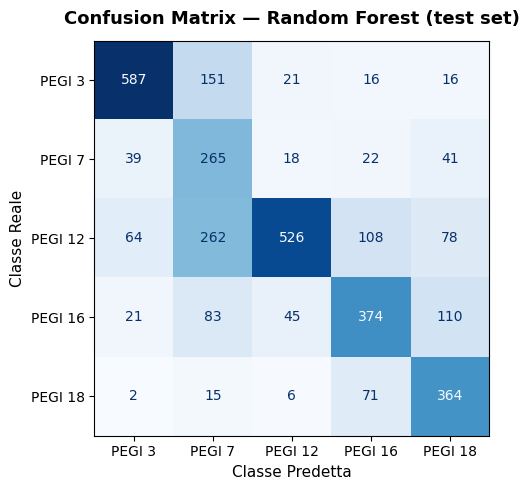

In [32]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[f'PEGI {c}' for c in rf_model.classes_],
    cmap='Blues',
    colorbar=False,
    ax=ax
)

ax.set_title('Confusion Matrix — Random Forest (test set)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Classe Predetta', fontsize=11)
ax.set_ylabel('Classe Reale', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. FEATURE IMPORTANCE — Impatto delle Feature Unsupervised

In [33]:
# ── Calcolo importanze ───────────────────────────────────────────────────────
importances  = rf_model.feature_importances_
fi_df        = pd.DataFrame({
    'feature'    : all_col_names,
    'importance' : importances,
    'is_kmeans'  : ['KMeans' if 'dist_cluster' in f else 'Tag Binario'
                    for f in all_col_names]
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Importanza aggregata per tipo di feature
type_summary = fi_df.groupby('is_kmeans')['importance'].sum().round(4)
print('Importanza TOTALE per tipo di feature:')
print(type_summary.to_string())
pct_kmeans = type_summary.get('KMeans', 0) / importances.sum() * 100
print(f'\n→ Le feature KMeans contribuiscono al {pct_kmeans:.1f}% dell\'importanza totale')
print('\nTop 20 feature più importanti:')
print(fi_df.head(20).to_string(index=False))

Importanza TOTALE per tipo di feature:
is_kmeans
KMeans         0.5411
Tag Binario    0.4589

→ Le feature KMeans contribuiscono al 54.1% dell'importanza totale

Top 20 feature più importanti:
            feature  importance   is_kmeans
     dist_cluster_8    0.076786      KMeans
     dist_cluster_2    0.075084      KMeans
     dist_cluster_3    0.065361      KMeans
     dist_cluster_9    0.056214      KMeans
     dist_cluster_6    0.049907      KMeans
     dist_cluster_0    0.048510      KMeans
     dist_cluster_1    0.043830      KMeans
     dist_cluster_4    0.042449      KMeans
     dist_cluster_5    0.042016      KMeans
     dist_cluster_7    0.040938      KMeans
         tag_Casual    0.038168 Tag Binario
     tag_Simulation    0.035308 Tag Binario
        tag_Violent    0.034025 Tag Binario
           tag_Gore    0.031956 Tag Binario
         tag_Action    0.026842 Tag Binario
          tag_Indie    0.023096 Tag Binario
         tag_Sports    0.016020 Tag Binario
         tag_Ra

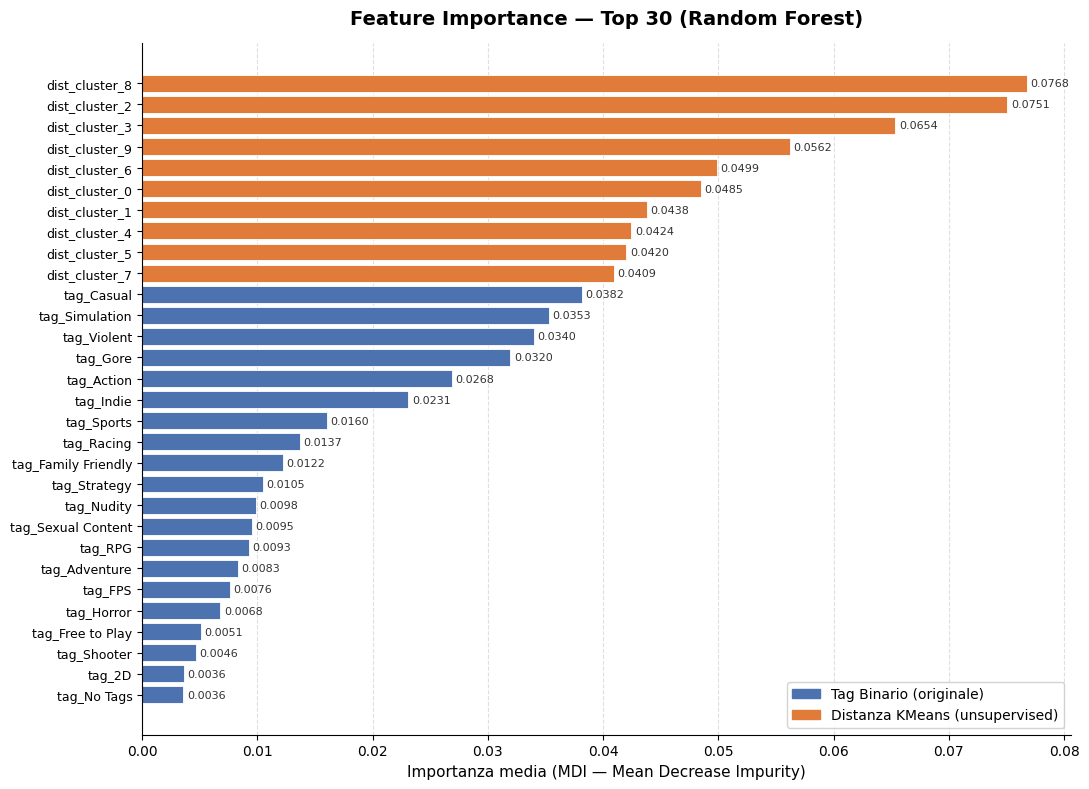

✅ Grafico salvato: feature_importance.png


In [34]:
# ── Grafico: Top-30 Feature Importance con evidenza KMeans ──────────────────
TOP_N = 30
top_fi = fi_df.head(TOP_N).copy()

# Colori: arancione per le distanze KMeans, blu per i tag binari
colors = ['#E07B39' if t == 'KMeans' else '#4C72B0' for t in top_fi['is_kmeans']]

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    y       = top_fi['feature'][::-1],
    width   = top_fi['importance'][::-1],
    color   = colors[::-1],
    edgecolor='white',
    linewidth=0.6
)

# Aggiunge il valore numerico a destra di ogni barra
for bar, val in zip(bars, top_fi['importance'][::-1]):
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=8, color='#333333')

# Legenda
from matplotlib.patches import Patch
legend_handles = [
    Patch(color='#4C72B0', label='Tag Binario (originale)'),
    Patch(color='#E07B39', label='Distanza KMeans (unsupervised)')
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=10,
          framealpha=0.85, edgecolor='#cccccc')

ax.set_title(f'Feature Importance — Top {TOP_N} (Random Forest)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Importanza media (MDI — Mean Decrease Impurity)', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafico salvato: feature_importance.png')

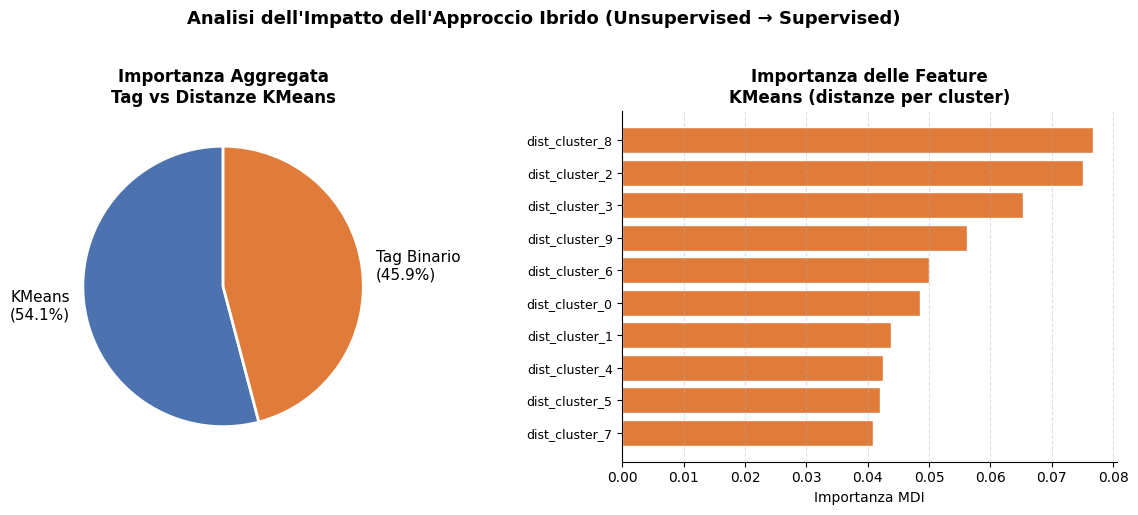

✅ Grafico salvato: hybrid_impact.png


In [35]:
# ── Grafico: Confronto importanza aggregata Tag vs KMeans (Pie + Bar) ────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Pie Chart ---
ax_pie = axes[0]
agg_importance = fi_df.groupby('is_kmeans')['importance'].sum()
pie_colors     = ['#4C72B0', '#E07B39']   # Tag Binario, KMeans
wedges, texts, autotexts = ax_pie.pie(
    agg_importance,
    labels       = [f'{k}\n({v:.1%})' for k, v in zip(agg_importance.index, agg_importance / agg_importance.sum())],
    autopct      = '',
    startangle   = 90,
    colors       = pie_colors,
    wedgeprops   = dict(edgecolor='white', linewidth=2),
    textprops    = dict(fontsize=11)
)
ax_pie.set_title('Importanza Aggregata\nTag vs Distanze KMeans', fontsize=12, fontweight='bold')

# --- Bar Chart: Top 10 KMeans features ---
ax_bar = axes[1]
top_kmeans = fi_df[fi_df['is_kmeans'] == 'KMeans'].head(K_OPTIMAL)

ax_bar.barh(
    y       = top_kmeans['feature'][::-1],
    width   = top_kmeans['importance'][::-1],
    color   = '#E07B39',
    edgecolor='white'
)
ax_bar.set_title('Importanza delle Feature\nKMeans (distanze per cluster)', fontsize=12, fontweight='bold')
ax_bar.set_xlabel('Importanza MDI', fontsize=10)
ax_bar.grid(axis='x', linestyle='--', alpha=0.4)
ax_bar.spines[['top','right']].set_visible(False)
ax_bar.tick_params(axis='y', labelsize=9)

plt.suptitle('Analisi dell\'Impatto dell\'Approccio Ibrido (Unsupervised → Supervised)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hybrid_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafico salvato: hybrid_impact.png')

---
## 7. ANALISI QUALITATIVA — Profilo dei Cluster PEGI

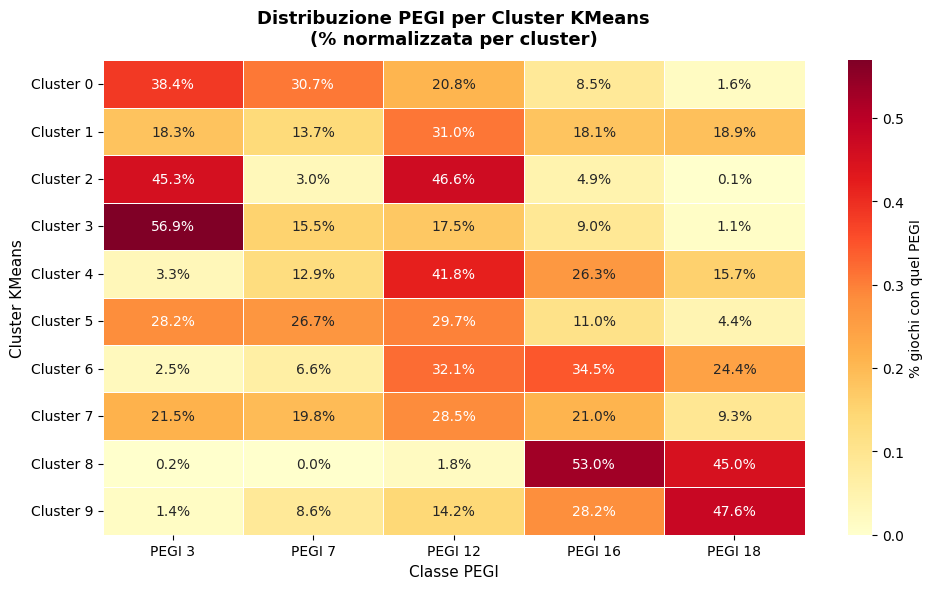

✅ Grafico salvato: cluster_pegi_heatmap.png


In [36]:
# ── Composizione PEGI per cluster (heatmap normalizzata) ────────────────────
df_analysis           = df.copy()
df_analysis['cluster'] = cluster_labels

cluster_pegi_dist = (
    df_analysis.groupby(['cluster', 'pegi'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda row: row / row.sum(), axis=1)   # normalizza per riga = % per cluster
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    cluster_pegi_dist,
    annot       = True,
    fmt         = '.1%',
    cmap        = 'YlOrRd',
    linewidths  = 0.5,
    linecolor   = 'white',
    cbar_kws    = {'label': '% giochi con quel PEGI'},
    ax          = ax
)
ax.set_title('Distribuzione PEGI per Cluster KMeans\n(% normalizzata per cluster)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Classe PEGI', fontsize=11)
ax.set_ylabel('Cluster KMeans', fontsize=11)
ax.set_xticklabels([f'PEGI {c}' for c in cluster_pegi_dist.columns], rotation=0)
ax.set_yticklabels([f'Cluster {i}' for i in cluster_pegi_dist.index], rotation=0)

plt.tight_layout()
plt.savefig('cluster_pegi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafico salvato: cluster_pegi_heatmap.png')

In [37]:
# ── Top-5 tag caratteristici per ogni cluster ─────────────────────────────────
print('TOP-5 TAG PER CLUSTER (tag più frequenti rispetto alla media globale)\n')
print('=' * 65)

global_freq = X_tags.mean(axis=0)   # frequenza media globale di ogni tag

for cluster_id in range(K_OPTIMAL):
    mask         = cluster_labels == cluster_id
    cluster_freq = X_tags[mask].mean(axis=0)                  # freq nel cluster
    lift         = cluster_freq - global_freq                  # differenza vs media
    top5_idx     = np.argsort(lift)[::-1][:5]
    top5_tags    = [VOCAB[i] for i in top5_idx]
    top5_lift    = [lift[i] for i in top5_idx]

    # PEGI prevalente nel cluster
    pegi_in_cluster = df_analysis.loc[mask, 'pegi']
    pegi_dominant   = pegi_in_cluster.mode()[0] if len(pegi_in_cluster) > 0 else '?'
    n_games         = mask.sum()

    print(f'Cluster {cluster_id:>2}  ({n_games:>4} giochi | PEGI prevalente: {pegi_dominant})')
    for tag, lft in zip(top5_tags, top5_lift):
        print(f'   +{lft:>5.3f}  {tag}')
    print()

TOP-5 TAG PER CLUSTER (tag più frequenti rispetto alla media globale)

Cluster  0  ( 945 giochi | PEGI prevalente: 3)
   +0.523  Singleplayer
   +0.509  2D
   +0.456  Arcade
   +0.352  Action
   +0.329  Indie

Cluster  1  (2095 giochi | PEGI prevalente: 12)
   +0.226  No Tags
   +0.116  Strategy
   +0.065  RPG
   +0.039  Racing
   +0.015  RTS

Cluster  2  (4049 giochi | PEGI prevalente: 12)
   +0.661  Simulation
   +0.206  Casual
   +0.075  Sports
   +0.026  Racing
   +0.000  Time Management

Cluster  3  ( 851 giochi | PEGI prevalente: 3)
   +0.573  Simulation
   +0.543  Singleplayer
   +0.420  Realistic
   +0.390  Multiplayer
   +0.345  Sandbox

Cluster  4  ( 699 giochi | PEGI prevalente: 12)
   +0.748  RPG
   +0.634  Singleplayer
   +0.592  Fantasy
   +0.525  Adventure
   +0.427  Story Rich

Cluster  5  (2112 giochi | PEGI prevalente: 12)
   +0.746  Indie
   +0.148  Adventure
   +0.100  Strategy
   +0.098  Casual
   +0.074  Action

Cluster  6  (3190 giochi | PEGI prevalente: 16)
   +

---
## 8. RIEPILOGO FINALE

In [40]:
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

# Calcolo metriche globali
f1_w  = f1_score(y_test, y_pred, average='weighted')
pre_w = precision_score(y_test, y_pred, average='weighted')
rec_w = recall_score(y_test, y_pred, average='weighted')

# Estrazione metriche per classe
report_dict = classification_report(y_test, y_pred, output_dict=True)

print('━' * 65)
print('  RIEPILOGO PIPELINE IBRIDA PEGI CLASSIFIER (DETTAGLIO CLASSI)')
print('━' * 65)
print(f'  Dataset:         {len(df):>6,} giochi con rating PEGI valido')
print(f'  Feature tag:     {X_tags.shape[1]:>6}  tag binari (freq ≥ {MIN_FREQ})')
print(f'  Feature KMeans:  {K_OPTIMAL:>6}  distanze dai centroidi')
print(f'  Feature totali:  {X_hybrid.shape[1]:>6}  (tag + distanze KMeans)')
print('  ' + '─' * 61)

# Intestazione tabella classi
print(f'  {"CLASSE":<10} | {"PRECISION":<10} | {"RECALL":<10} | {"F1-SCORE":<10}')
print('  ' + '─' * 61)

for cls in sorted(rf_model.classes_):
    label = f'PEGI {int(cls)}'
    metrics = report_dict[str(int(cls))]
    print(f"  {label:<10} | {metrics['precision']:>10.4f} | {metrics['recall']:>10.4f} | {metrics['f1-score']:>10.4f}")

print('  ' + '─' * 61)
print(f'  Accuracy (test):     {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  F1-Score  weighted:  {f1_w:.4f}')
print(f'  CV F1 (5-fold):      {cvs.mean():.4f} ± {cvs.std():.4f}')
print('  ' + '─' * 61)
print(f'  Contributo KMeans:   {pct_kmeans:.1f}% dell\'importanza totale')
print('━' * 65)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RIEPILOGO PIPELINE IBRIDA PEGI CLASSIFIER (DETTAGLIO CLASSI)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dataset:         16,524 giochi con rating PEGI valido
  Feature tag:        245  tag binari (freq ≥ 50)
  Feature KMeans:      10  distanze dai centroidi
  Feature totali:     255  (tag + distanze KMeans)
  ─────────────────────────────────────────────────────────────
  CLASSE     | PRECISION  | RECALL     | F1-SCORE  
  ─────────────────────────────────────────────────────────────
  PEGI 3     |     0.8233 |     0.7421 |     0.7806
  PEGI 7     |     0.3415 |     0.6883 |     0.4565
  PEGI 12    |     0.8539 |     0.5067 |     0.6360
  PEGI 16    |     0.6328 |     0.5908 |     0.6111
  PEGI 18    |     0.5977 |     0.7948 |     0.6823
  ─────────────────────────────────────────────────────────────
  Accuracy (test):     0.6402  (64.02%)
  F1-Score  weighted:  0.6514
  CV F1 (5-fold):      0

---

## 9. Salva il Modello e i Componenti per la Deployment

In [39]:
import joblib

# Salva il modello Random Forest
joblib.dump(rf_model, 'random_forest_model.pkl')
print('Modello Random Forest salvato come random_forest_model.pkl')

# Salva il modello KMeans
joblib.dump(kmeans, 'kmeans_model.pkl')
print('Modello KMeans salvato come kmeans_model.pkl')

# Salva il vocabolario dei tag
joblib.dump(VOCAB, 'tag_vocabulary.pkl')
print('Vocabolario dei tag salvato come tag_vocabulary.pkl')

# Potresti anche voler salvare le classi PEGI e la frequenza minima dei tag
joblib.dump(PEGI_CLASSES, 'pegi_classes.pkl')
joblib.dump(MIN_FREQ, 'min_freq.pkl')
print('Classi PEGI e MIN_FREQ salvati.')

Modello Random Forest salvato come random_forest_model.pkl
Modello KMeans salvato come kmeans_model.pkl
Vocabolario dei tag salvato come tag_vocabulary.pkl
Classi PEGI e MIN_FREQ salvati.


Una volta eseguiti questi passaggi, potrai scaricare i seguenti file per la tua web app:
- `random_forest_model.pkl`
- `kmeans_model.pkl`
- `tag_vocabulary.pkl`
- `pegi_classes.pkl`
- `min_freq.pkl`

Questi file contengono il modello addestrato e i dati necessari per riprodurre la pipeline di preprocessing e fare previsioni nella tua applicazione.